In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'computers.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(480, 640, 3)

In [3]:
h, w = img.shape[:2]
pad_top, pad_left = 80, 150

world = cv2.copyMakeBorder(img, pad_top, 0, pad_left, 0, cv2.BORDER_CONSTANT, value=(210, 190, 150))
mark = (60, 40)
cv2.line(world, (mark[0] - 20, mark[1] - 20), (mark[0] + 20, mark[1] + 20), (255, 0, 0), 6)
cv2.line(world, (mark[0] - 20, mark[1] + 20), (mark[0] + 20, mark[1] - 20), (255, 0, 0), 6)
world.shape

(560, 790, 3)

In [4]:
D = np.array([[1, 0, -150], [0, 1, -80], [0, 0, 1]], dtype=np.float64)
T = np.array([[1, 0, 150], [0, 1, 80], [0, 0, 1]], dtype=np.float64)

before = cv2.warpAffine(world, D[:2], (w, h))
fixed = cv2.warpAffine(world, (T @ D)[:2], (w, h))

p = np.array([mark[0], mark[1], 1])
print('X before:', (D @ p)[:2])
print('X after:', (T @ D @ p)[:2])

X before: [-90. -40.]
X after: [60. 40.]


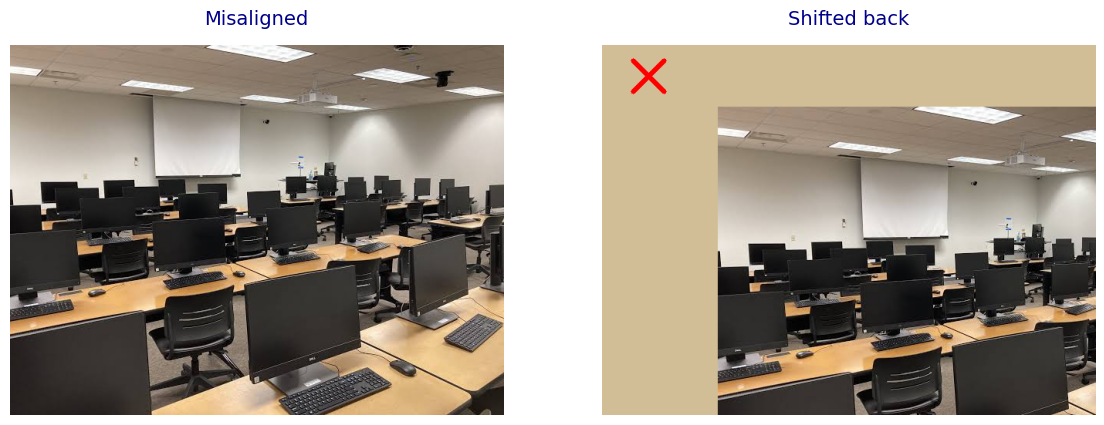

In [5]:
panels = [('Misaligned', before), ('Shifted back', fixed)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [6]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task4_map.png', cv2.cvtColor(fixed, cv2.COLOR_RGB2BGR))

True

Translation can't be written as a 2x2 matrix since it adds a constant instead of multiplying. Using 3x3 with a third row [0, 0, 1] and the point as (x, y, 1) puts tx and ty in the last column.

The map was offset by (-150, -80) so the X at (60, 40) ended up at (-90, -40), off screen. T = [[1, 0, 150], [0, 1, 80], [0, 0, 1]] moves every pixel right 150 and down 80 and the X comes back to (60, 40). Applying T after D gives the identity so the map is back where it should be.